
# Analysis



In [1]:
import onstove
print("OnStove is ready!")




OnStove is ready!


In [2]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from onstove.model import OnStove

from onstove.technology import Technology

# Visualization

In [7]:

# Assume each admin region has the same average energy demand
energy_demand_kwh = 100  # example demand per household per month

# Compute estimated monthly cooking cost for each technology
energy["monthly_cost"] = energy["cost_per_kg"] * energy_demand_kwh

# Determine least-cost technology
min_cost = energy["monthly_cost"].min()
least_cost_tech = energy.loc[energy["monthly_cost"].idxmin(), "technology"]

print(f"✅ Least-cost technology: {least_cost_tech}")
print(energy)


✅ Least-cost technology: Charcoal
     technology  cost_per_kg  efficiency  lifetime_years  emission_factor  \
0           LPG         2.00        0.65              10            2.983   
1        Biogas         1.20        0.55              10            1.500   
2      Charcoal         0.80        0.40               5            4.300   
3   Electricity         3.50        0.80              10            0.200   
4       Ethanol         2.20        0.60               8            1.800   
5   Electricity         3.64        0.82              12            0.167   
6        Biogas         1.31        0.50              10            1.465   
7      Charcoal         0.67        0.44              12            4.442   
8   Electricity         3.67        0.75              15            0.110   
9      Charcoal         0.67        0.38              15            4.447   
10  Electricity         3.30        0.81              10            0.296   
11  Electricity         3.56        0.82  

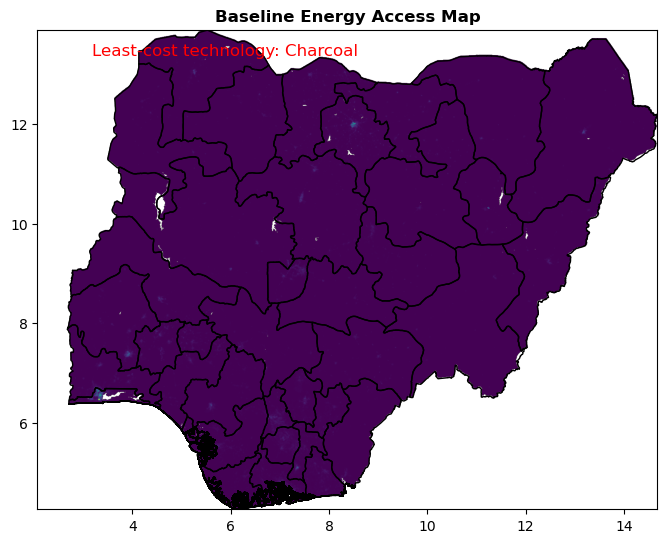

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot raster (population density)
show(raster, ax=ax, title="Baseline Energy Access Map")

# Overlay admin boundaries
admin.boundary.plot(ax=ax, color="black", linewidth=1)

# Title annotation
plt.text(
    x=admin.total_bounds[0] + 0.5,
    y=admin.total_bounds[3] - 0.5,
    s=f"Least-cost technology: {least_cost_tech}",
    fontsize=12,
    color="red"
)

plt.show()


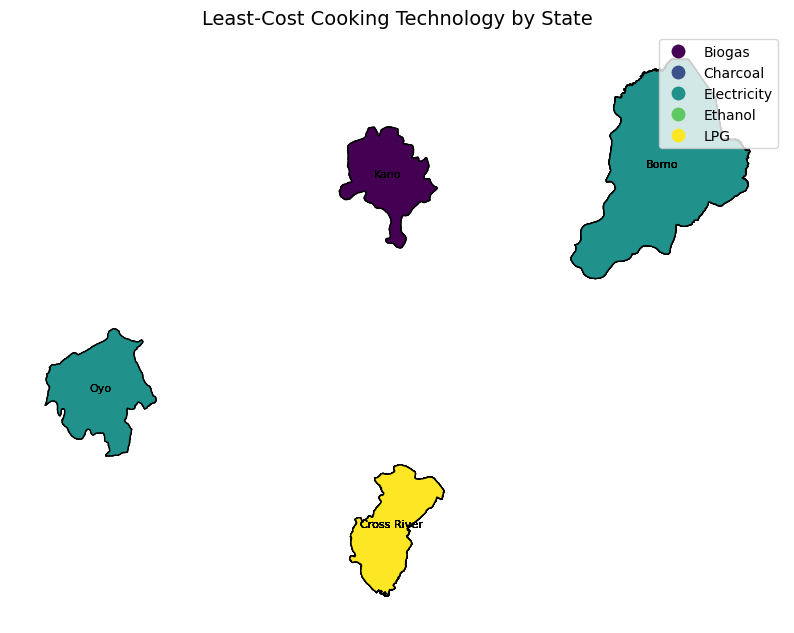

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load shapefile (state boundaries)
admin1 = gpd.read_file("data/nigeria_admin1.shp")

# Load updated CSV (must have a 'State' column)
energy_cost = pd.read_csv("data/energy_cost_data.csv")

# Merge shapefile and data
merged = admin1.merge(energy_cost, left_on="NAME_1", right_on="State")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
merged.plot(column="technology", ax=ax, legend=True, cmap="viridis", edgecolor="black")

# Add state names at centroid positions
for idx, row in merged.iterrows():
    plt.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["NAME_1"],
        fontsize=8,
        ha='center',
        color='black'
    )

# Title and display
plt.title("Least-Cost Cooking Technology by State", fontsize=14)
plt.axis("off")
plt.show()


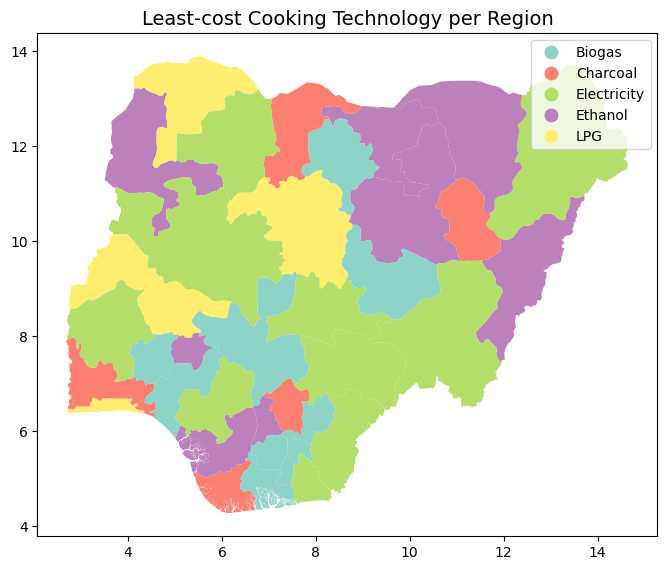

In [10]:
import numpy as np

# Example: randomly assign a cost per admin region to simulate spatial difference
np.random.seed(42)
energy_options = ["LPG", "Charcoal", "Electricity","Biogas", "Ethanol"]

admin["least_cost"] = np.random.choice(energy_options, size=len(admin))

# Plot the results
fig, ax = plt.subplots(figsize=(8, 8))
admin.plot(column="least_cost", cmap="Set3", legend=True, ax=ax)
plt.title("Least-cost Cooking Technology per Region", fontsize=14)
plt.show()


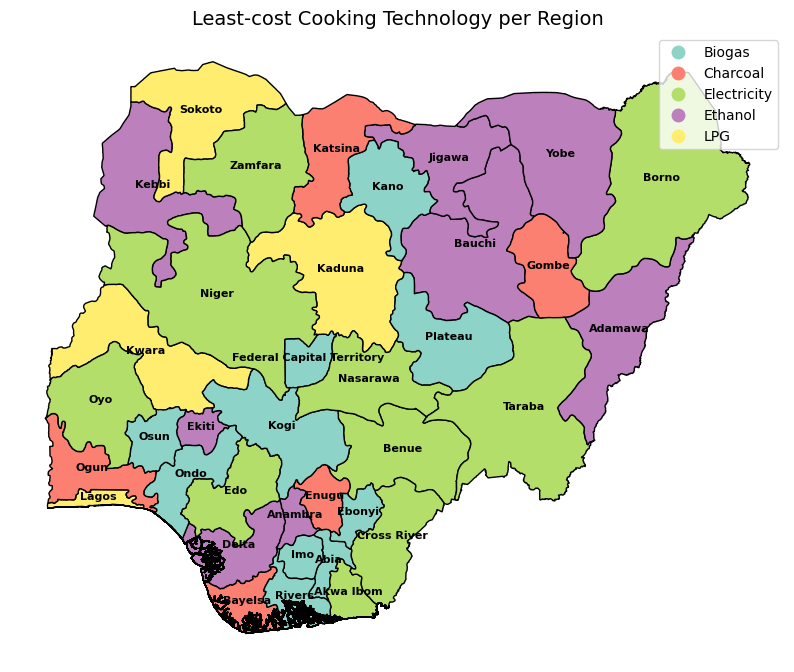

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# Example: randomly assign a cost per admin region to simulate spatial difference
np.random.seed(42)
energy_options = ["LPG", "Charcoal", "Electricity", "Biogas", "Ethanol"]

# Assuming 'admin' is your GeoDataFrame with state/region boundaries
admin["least_cost"] = np.random.choice(energy_options, size=len(admin))

# Plot the results
fig, ax = plt.subplots(figsize=(10, 10))
admin.plot(column="least_cost", cmap="Set3", legend=True, ax=ax, edgecolor='black')

# Add region/state names at the centroid of each polygon
for idx, row in admin.iterrows():
    plt.text(
        row.geometry.centroid.x, 
        row.geometry.centroid.y, 
        row['NAME_1'],  
        fontsize=8,
        ha='center',
        color='black',
        weight='bold'
    )

# Title and display
plt.title("Least-cost Cooking Technology per Region", fontsize=14)
plt.axis('off')
plt.show()



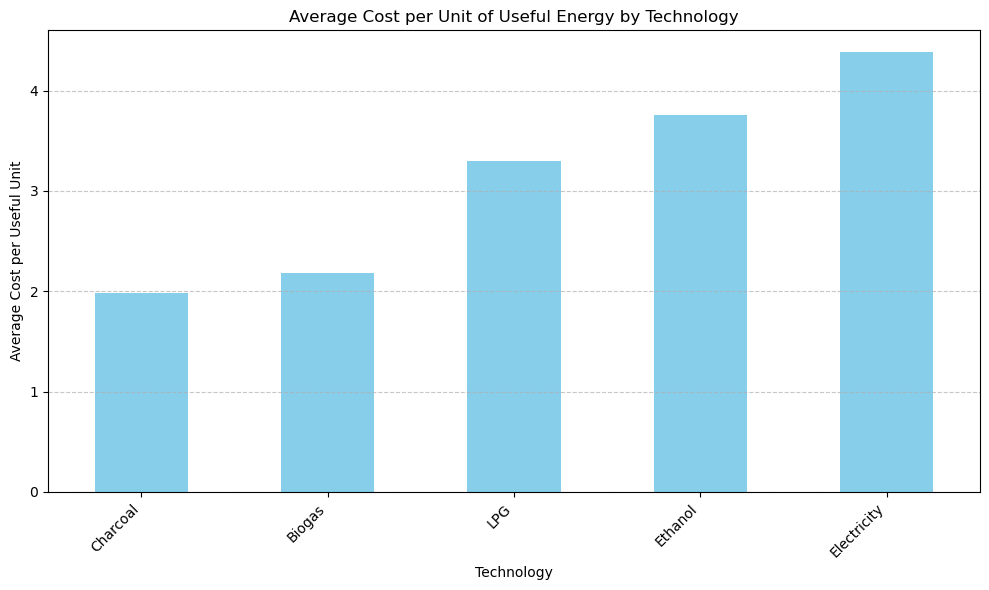

In [12]:
# Formula: Cost_per_useful_unit = cost_per_kg / efficiency
energy_cost['cost_per_useful_unit'] = energy_cost['cost_per_kg'] / energy_cost['efficiency']

# --- 2. Calculate the average cost for each technology and sort ---
# Group by technology and find the mean cost, then sort from lowest to highest.
cost_summary = energy_cost.groupby('technology')['cost_per_useful_unit'].mean().sort_values(ascending=True)

# --- 3. Create the Bar Chart ---
plt.figure(figsize=(10, 6))
cost_summary.plot(kind='bar', color='skyblue')

# Add titles and labels
plt.title('Average Cost per Unit of Useful Energy by Technology')
plt.xlabel('Technology')
plt.ylabel('Average Cost per Useful Unit')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


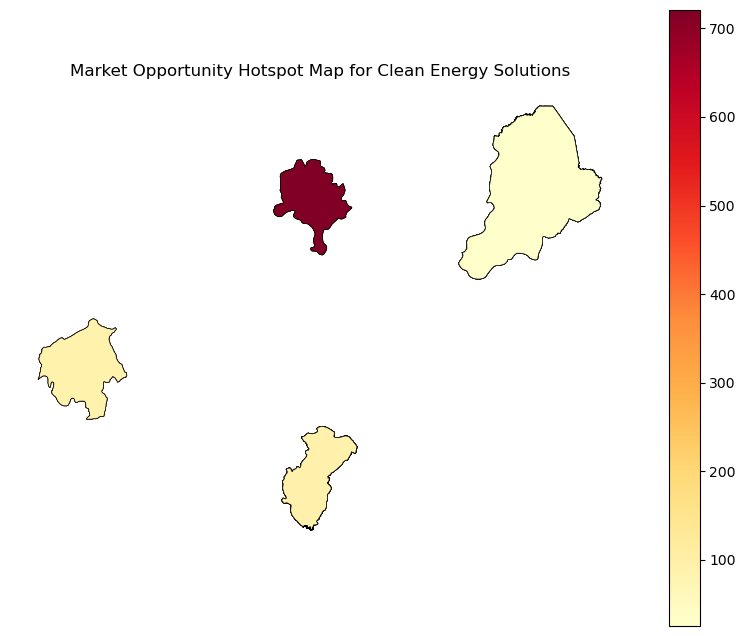

In [13]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats   # <-- FIXED
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Load shapefile + population raster + energy cost data
# -----------------------------
admin1 = gpd.read_file("data/nigeria_admin1.shp")   # contains NAME_1
pop_raster = "data/nigeria_population.tif"

energy_cost = pd.read_csv("data/energy_cost_data.csv")   # contains State

# -----------------------------
# 2. Compute mean population per state (zonal statistics)
# -----------------------------
pop_stats = zonal_stats(
    admin1,
    pop_raster,
    stats=["mean"],
    geojson_out=True
)

pop_gdf = gpd.GeoDataFrame.from_features(pop_stats)
pop_gdf.rename(columns={"mean": "mean_pop"}, inplace=True)

# -----------------------------
# 3. Merge pop stats with energy cost data
# -----------------------------
merged = pop_gdf.merge(
    energy_cost,
    left_on="NAME_1",      # shapefile
    right_on="State",      # CSV
    how="left"
)

# -----------------------------
# 4. Compute market opportunity score
#    (high population + low cost = better)
# -----------------------------
merged["opportunity_index"] = merged["mean_pop"] / merged["cost_per_kg"]

# -----------------------------
# 5. Plot Hotspot Map
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

merged.plot(
    column="opportunity_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

plt.title("Market Opportunity Hotspot Map for Clean Energy Solutions")
plt.axis("off")
plt.show()



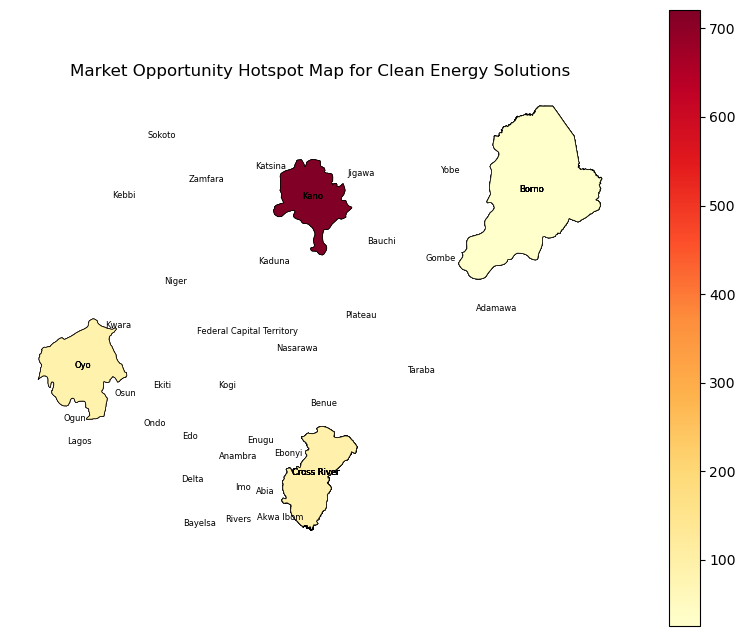

In [18]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1. Load shapefile + population raster + energy cost data
# -----------------------------
admin1 = gpd.read_file("data/nigeria_admin1.shp")
pop_raster = "data/nigeria_population.tif"

energy_cost = pd.read_csv("data/energy_cost_data.csv")

# -----------------------------
# 2. Zonal Statistics
# -----------------------------
pop_stats = zonal_stats(
    admin1,
    pop_raster,
    stats=["mean"],
    geojson_out=True
)

pop_gdf = gpd.GeoDataFrame.from_features(pop_stats)
pop_gdf.rename(columns={"mean": "mean_pop"}, inplace=True)

# -----------------------------
# 3. Merge
# -----------------------------
merged = pop_gdf.merge(
    energy_cost,
    left_on="NAME_1",
    right_on="State",
    how="left"
)

# -----------------------------
# 4. Compute Opportunity Index
# -----------------------------
merged["opportunity_index"] = merged["mean_pop"] / merged["cost_per_kg"]

# -----------------------------
# 5. Plot + SAVE MAP
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

merged.plot(
    column="opportunity_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

plt.title("Market Opportunity Hotspot Map for Clean Energy Solutions")
plt.axis("off")

# -----------------------------
# 6. Add State Labels
# -----------------------------
for _, row in merged.iterrows():
    if row["geometry"].geom_type == "Polygon":
        x, y = row["geometry"].centroid.coords[0]
    else:  # MultiPolygon
        x, y = row["geometry"].centroid.coords[0]

    plt.text(
        x,
        y,
        row["NAME_1"],        # or row["State"] depending on your field
        horizontalalignment='center',
        fontsize=6,
        color='black'
    )
# ⭐ SAVE THE IMAGE HERE ⭐
fig.savefig("market_hotspot.png", dpi=100, bbox_inches="tight")


plt.show()
